# Bernoulli experiment & Latent Ability Estimation (logistic link)

- A student is trying to solve N=20 problems and the result is a sequence of 0's and 1's.
  - 이는 이 학생이 난도가 동일한 20개의 문제를 푸는 것이다. 맞으면 1점, 틀리면 0점.
  - 이는 난도가 정해진 하나의 문제를 20회 반복하여 푸는 것과 동일하다. (문제를 기억하지 않는다는 조건에서.)
- The probability of answering a question correctly is $\phi$.
- $\phi$ is obtained from the **latent ability** $\theta$ through the logistic function:
      $\phi = \text{logistic}(\theta) = \dfrac{1}{1+e^{-\theta}}, \quad -\infty < \theta < \infty$
- $Y_i \sim \text{Bernoulli}(\phi) = \text{Bernoulli}(\text{logistic}(\theta))$
- Question: What is the posterior probability of $\theta$ when a set of observations is provided?
- Data are obtained by simulation. The true value $\theta_{\text{true}}$ exists only as a simulation parameter and is unknown to the model.
- Stan/cmdstanpy & plots

## Table of Contents

1. 데이터와 문제 설정 (시뮬레이션)
2. Bayesian 모델 (Stan/cmdstanpy)
3. Posterior 요약과 시각화
4. Grid 근사 posterior와 비교, 사후예측분포
5. 결론
6. Prior sensitivity: Normal(μ, σ) prior 비교
7. Normal prior on θ → φ 공간에서의 prior 모양
8. Posterior predictive checks with different priors

## 1. 데이터와 문제 설정 (시뮬레이션)

학생의 잠재능력 $\theta$ 의 참값 $\theta_{\text{true}}$ 를 정하고, 이로부터 정답확률 $\phi_{\text{true}} = \text{logistic}(\theta_{\text{true}})$ 를 계산한 뒤
N=20개의 0/1 응답을 생성한다.

- $\theta_{\text{true}}$ 는 **시뮬레이션 파라메터로만 존재**한다. 추정 과정(Stan 모델)에는 관측값 $y$ 만 전달된다.
- 참값은 추정이 끝난 후 결과를 평가할 때에만 사용한다.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cmdstanpy import CmdStanModel

SEED = 42
rng = np.random.default_rng(SEED)

def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def logit(p):
    return np.log(p) - np.log1p(-p)

# ----- 시뮬레이션 파라메터 (모델은 이 값을 모른다) -----
THETA_TRUE = 0.8
PHI_TRUE = logistic(THETA_TRUE)

N = 20
y = rng.binomial(n=1, p=PHI_TRUE, size=N).astype(int)

k = int(y.sum())
print("y =", y)
print(f"N={N}, success={k}, failure={N-k}, sample proportion={k/N:.3f}")

y = [0 1 0 0 1 0 0 0 1 1 1 0 1 0 1 1 1 1 0 1]
N=20, success=11, failure=9, sample proportion=0.550


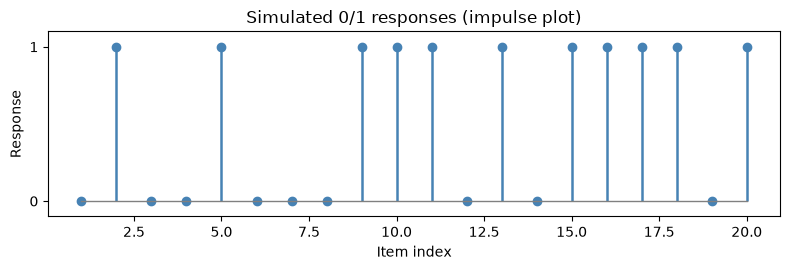

In [2]:
x = np.arange(1, N + 1)

plt.figure(figsize=(8, 2.8))
markerline, stemlines, baseline = plt.stem(x, y, linefmt="steelblue", markerfmt="o", basefmt="k-")
plt.setp(markerline, markerfacecolor="steelblue", markeredgecolor="steelblue")
plt.setp(stemlines, linewidth=1.8, color="steelblue")
plt.setp(baseline, linewidth=1.0, color="gray")

plt.yticks([0, 1])
plt.ylim(-0.1, 1.1)
plt.xlabel("Item index")
plt.ylabel("Response")
plt.title("Simulated 0/1 responses (impulse plot)")
plt.tight_layout()
plt.show()

## 2. Bayesian 모델

모형:
- $Y_i \sim \text{Bernoulli}(\phi), \quad \phi = \text{logistic}(\theta)$
- $\theta \sim \text{Normal}(\mu_0, \sigma_0)$, 기본 설정은 $\mu_0 = 0,\ \sigma_0 = 1.5$

특징:
- $\theta$ 는 실수 전체에서 정의되므로 Normal prior를 자연스럽게 사용할 수 있다.
- Normal prior와 Bernoulli-logistic likelihood는 **conjugate가 아니다**. 따라서 posterior는 닫힌형식으로 주어지지 않고, MCMC(Stan)로 샘플을 얻는다.
- Stan의 `bernoulli_logit(theta)` 는 `bernoulli(inv_logit(theta))` 와 같지만 수치적으로 더 안정적이다.
- `generated quantities` 에서 $\phi$ 와 다음 10문항의 예측 정답 수를 함께 계산한다.

아래 그림은 logistic 함수가 실수 $\theta$ 를 (0, 1) 구간의 확률 $\phi$ 로 바꾸는 모양이다.

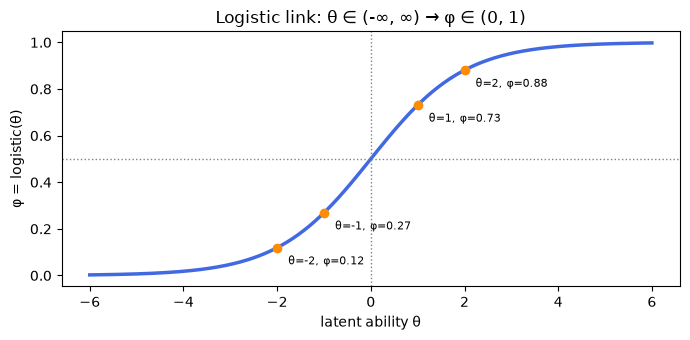

In [3]:
theta_grid = np.linspace(-6, 6, 400)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(theta_grid, logistic(theta_grid), color="royalblue", linewidth=2.5)
ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
ax.axvline(0.0, color="gray", linestyle=":", linewidth=1)
for thv in [-2, -1, 1, 2]:
    ax.plot(thv, logistic(thv), "o", color="darkorange")
    ax.annotate(f"θ={thv}, φ={logistic(thv):.2f}", (thv, logistic(thv)),
                textcoords="offset points", xytext=(8, -12), fontsize=8)
ax.set_xlabel("latent ability θ")
ax.set_ylabel("φ = logistic(θ)")
ax.set_title("Logistic link: θ ∈ (-∞, ∞) → φ ∈ (0, 1)")
plt.tight_layout()
plt.show()

In [4]:
stan_code = '''
data {
  int<lower=1> N;
  array[N] int<lower=0,upper=1> y;
  real mu0;              // prior mean of theta
  real<lower=0> sigma0;  // prior sd of theta
  int<lower=0> N_new;    // number of future problems for prediction
}
parameters {
  real theta;           // latent ability
}
model {
  theta ~ normal(mu0, sigma0);
  y ~ bernoulli_logit(theta);   // y ~ bernoulli(inv_logit(theta))
}
generated quantities {
  real phi = inv_logit(theta);
  int k_new = binomial_rng(N_new, phi);
}
'''

with open("bernoulli_logistic_estimation.stan", "w", encoding="utf-8") as f:
    f.write(stan_code)

model = CmdStanModel(stan_file="bernoulli_logistic_estimation.stan")

MU0, SIGMA0 = 0.0, 1.5
N_NEW = 10

fit = model.sample(
    data={"N": int(N), "y": y.tolist(), "mu0": MU0, "sigma0": SIGMA0, "N_new": N_NEW},
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=2000,
    seed=SEED,
    show_progress=False,
)

posterior = fit.draws_pd(vars=["theta", "phi", "k_new"])
theta_samples = posterior["theta"].to_numpy()
phi_samples = posterior["phi"].to_numpy()
k_new_samples = posterior["k_new"].to_numpy().astype(int)

summary = fit.summary()

# CmdStanPy version마다 summary 컬럼명이 다를 수 있어, 존재하는 컬럼만 선택해서 출력
candidate_cols = ["Mean", "mean", "SD", "sd", "StdDev", "2.5%", "5%", "50%", "95%", "97.5%",
                  "N_Eff", "ESS_bulk", "R_hat", "R_hat"]
available_cols = list(dict.fromkeys(c for c in candidate_cols if c in summary.columns))
rows = [r for r in ["theta", "phi"] if r in summary.index]
print(summary.loc[rows, available_cols] if available_cols else summary.loc[rows])

           Mean    StdDev        5%       50%       95%  ESS_bulk    R_hat
theta  0.189632  0.443612 -0.552146  0.192553  0.917105   2337.99  1.00172
phi    0.545199  0.105284  0.365367  0.547990  0.714452   2337.99  1.00172


R_hat 이 1에 가깝고 유효표본크기(ESS/N_Eff)가 충분히 크면 4개 체인이 잘 수렴했다고 판단한다.

## 3. Posterior 요약과 시각화

$\theta$ 의 posterior 평균, 중앙값, 95% credible interval을 계산하고 분포를 시각화한다.
$\phi = \text{logistic}(\theta)$ 는 단조증가 함수이므로 각 샘플에 변환을 적용하면 곧바로 $\phi$ 의 posterior 샘플이 된다.

이제 처음으로 시뮬레이션 참값 $\theta_{\text{true}}$ 와 비교해 본다.

In [5]:
theta_mean = theta_samples.mean()
theta_median = np.median(theta_samples)
theta_low, theta_high = np.quantile(theta_samples, [0.025, 0.975])

phi_mean = phi_samples.mean()
phi_low, phi_high = np.quantile(phi_samples, [0.025, 0.975])

print(f"Posterior mean(theta)  : {theta_mean:.4f}")
print(f"Posterior median(theta): {theta_median:.4f}")
print(f"95% CrI(theta)         : ({theta_low:.4f}, {theta_high:.4f})")
print(f"True theta (simulation): {THETA_TRUE:.4f}  -> inside 95% CrI? {theta_low <= THETA_TRUE <= theta_high}")
print()
print(f"Posterior mean(phi)   : {phi_mean:.4f}")
print(f"95% CrI(phi)          : ({phi_low:.4f}, {phi_high:.4f})")
print(f"True phi (simulation) : {PHI_TRUE:.4f}")
print(f"logistic(posterior mean of theta) = {logistic(theta_mean):.4f}  (≠ posterior mean of phi)")

Posterior mean(theta)  : 0.1896
Posterior median(theta): 0.1926
95% CrI(theta)         : (-0.6810, 1.0618)
True theta (simulation): 0.8000  -> inside 95% CrI? True

Posterior mean(phi)   : 0.5452
95% CrI(phi)          : (0.3360, 0.7430)
True phi (simulation) : 0.6900
logistic(posterior mean of theta) = 0.5473  (≠ posterior mean of phi)


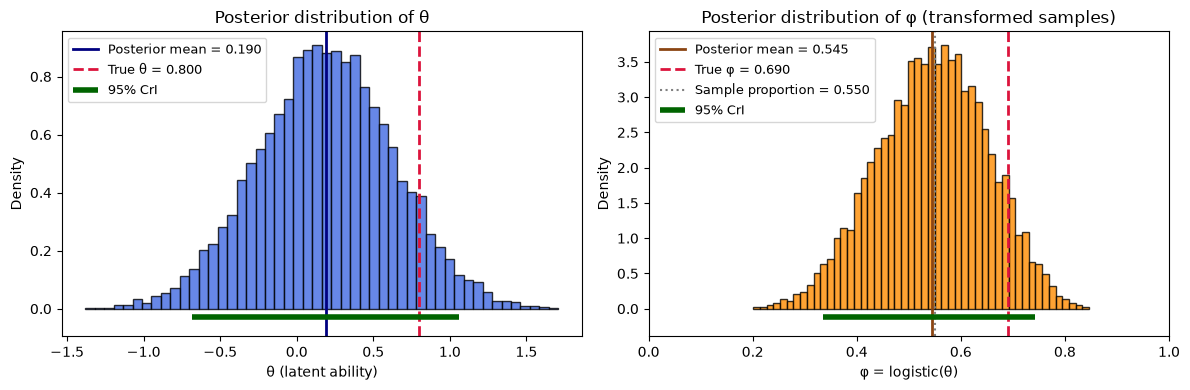

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# (a) theta posterior
ax = axes[0]
ax.hist(theta_samples, bins=50, color="royalblue", edgecolor="black", alpha=0.8, density=True)
ax.axvline(theta_mean, color="navy", linewidth=2, label=f"Posterior mean = {theta_mean:.3f}")
ax.axvline(THETA_TRUE, color="crimson", linewidth=2, linestyle="--", label=f"True θ = {THETA_TRUE:.3f}")
top = ax.get_ylim()[1]
ax.hlines(y=-0.03 * top, xmin=theta_low, xmax=theta_high, color="darkgreen", linewidth=4, label="95% CrI")
ax.set_ylim(bottom=-0.1 * top, top=top)
ax.set_xlabel("θ (latent ability)")
ax.set_ylabel("Density")
ax.set_title("Posterior distribution of θ")
ax.legend(fontsize=9)

# (b) phi posterior (transformed samples)
ax = axes[1]
ax.hist(phi_samples, bins=50, color="darkorange", edgecolor="black", alpha=0.8, density=True)
ax.axvline(phi_mean, color="saddlebrown", linewidth=2, label=f"Posterior mean = {phi_mean:.3f}")
ax.axvline(PHI_TRUE, color="crimson", linewidth=2, linestyle="--", label=f"True φ = {PHI_TRUE:.3f}")
ax.axvline(k / N, color="gray", linewidth=1.5, linestyle=":", label=f"Sample proportion = {k/N:.3f}")
top = ax.get_ylim()[1]
ax.hlines(y=-0.03 * top, xmin=phi_low, xmax=phi_high, color="darkgreen", linewidth=4, label="95% CrI")
ax.set_ylim(bottom=-0.1 * top, top=top)
ax.set_xlim(0, 1)
ax.set_xlabel("φ = logistic(θ)")
ax.set_ylabel("Density")
ax.set_title("Posterior distribution of φ (transformed samples)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

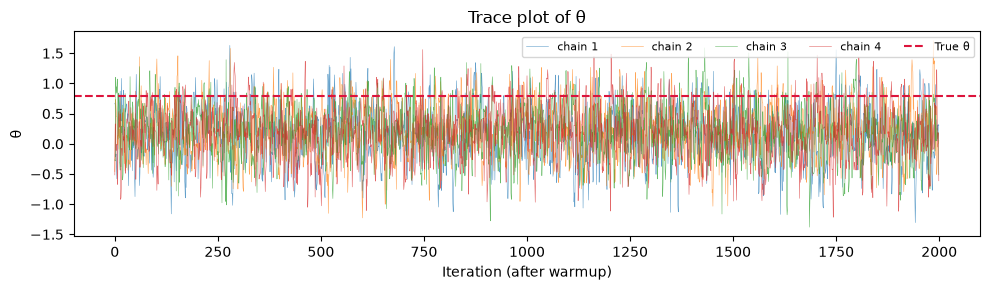

In [7]:
# Trace plot: 4 chains for theta
# stan_variable()은 체인 순서대로 이어붙인 샘플을 반환하므로 (chains, iter_sampling)으로 reshape
theta_by_chain = fit.stan_variable("theta").reshape(fit.chains, -1)
fig, ax = plt.subplots(figsize=(10, 3))
for c in range(theta_by_chain.shape[0]):
    ax.plot(theta_by_chain[c], linewidth=0.4, alpha=0.7, label=f"chain {c+1}")
ax.axhline(THETA_TRUE, color="crimson", linestyle="--", linewidth=1.5, label="True θ")
ax.set_xlabel("Iteration (after warmup)")
ax.set_ylabel("θ")
ax.set_title("Trace plot of θ")
ax.legend(fontsize=8, ncol=5, loc="upper right")
plt.tight_layout()
plt.show()

## 4. Grid 근사 posterior와 비교, 사후예측분포

Normal prior + logistic likelihood는 conjugate가 아니므로 닫힌형식 posterior는 없다.
그러나 파라메터가 1개뿐이므로 $\theta$ 격자(grid) 위에서 비정규화 posterior를 직접 계산하고 수치적으로 정규화할 수 있다.

$$
p(\theta \mid y) \propto \text{Normal}(\theta \mid \mu_0, \sigma_0)\ \phi^{k} (1-\phi)^{N-k}, \qquad \phi = \text{logistic}(\theta)
$$

$\phi$ 공간의 밀도는 변수변환 공식으로 얻는다. $d\theta / d\phi = 1 / \{\phi(1-\phi)\}$ 이므로

$$
p(\phi \mid y) = p(\theta = \text{logit}(\phi) \mid y) \cdot \frac{1}{\phi(1-\phi)}
$$

Stan 샘플 기반 추정과 grid 근사가 일관적인지 확인한다.

Grid posterior mean(theta): 0.1921
Stan posterior mean(theta): 0.1896


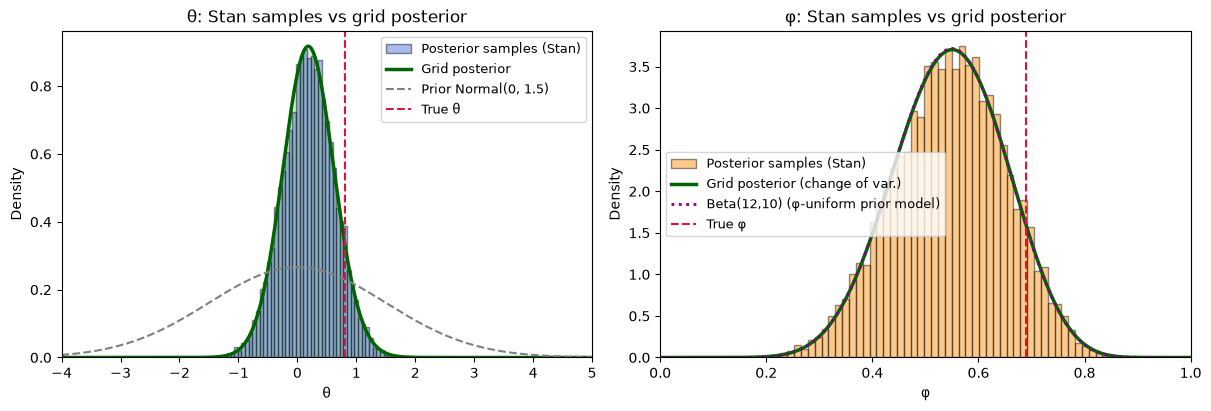

In [8]:
from scipy.stats import norm, beta

theta_grid = np.linspace(-5, 6, 2001)
phi_on_grid = logistic(theta_grid)

# log unnormalized posterior on the theta grid (numerically stable form)
log_prior = norm.logpdf(theta_grid, MU0, SIGMA0)
log_lik = k * np.log(phi_on_grid) + (N - k) * np.log1p(-phi_on_grid)
log_post = log_prior + log_lik
post_theta_grid = np.exp(log_post - log_post.max())
post_theta_grid /= np.trapezoid(post_theta_grid, theta_grid)

grid_mean = np.trapezoid(theta_grid * post_theta_grid, theta_grid)
print(f"Grid posterior mean(theta): {grid_mean:.4f}")
print(f"Stan posterior mean(theta): {theta_mean:.4f}")

# phi-space density by change of variables
phi_grid = np.linspace(0.001, 0.999, 999)
theta_of_phi = logit(phi_grid)
post_phi_grid = np.interp(theta_of_phi, theta_grid, post_theta_grid) / (phi_grid * (1 - phi_grid))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax = axes[0]
ax.hist(theta_samples, bins=50, density=True, color="royalblue", alpha=0.45, edgecolor="black",
        label="Posterior samples (Stan)")
ax.plot(theta_grid, post_theta_grid, color="darkgreen", linewidth=2.5, label="Grid posterior")
ax.fill_between(theta_grid, post_theta_grid, color="darkgreen", alpha=0.15)
ax.plot(theta_grid, norm.pdf(theta_grid, MU0, SIGMA0), color="gray", linestyle="--",
        label=f"Prior Normal({MU0:g}, {SIGMA0:g})")
ax.axvline(THETA_TRUE, color="crimson", linestyle="--", linewidth=1.5, label="True θ")
ax.set_xlim(-4, 5)
ax.set_xlabel("θ")
ax.set_ylabel("Density")
ax.set_title("θ: Stan samples vs grid posterior")
ax.legend(fontsize=9)

ax = axes[1]
ax.hist(phi_samples, bins=50, density=True, color="darkorange", alpha=0.45, edgecolor="black",
        label="Posterior samples (Stan)")
ax.plot(phi_grid, post_phi_grid, color="darkgreen", linewidth=2.5, label="Grid posterior (change of var.)")
ax.plot(phi_grid, beta.pdf(phi_grid, 1 + k, 1 + N - k), color="purple", linestyle=":", linewidth=2,
        label=f"Beta({1+k},{1+N-k}) (φ-uniform prior model)")
ax.axvline(PHI_TRUE, color="crimson", linestyle="--", linewidth=1.5, label="True φ")
ax.set_xlim(0, 1)
ax.set_xlabel("φ")
ax.set_ylabel("Density")
ax.set_title("φ: Stan samples vs grid posterior")
ax.legend(fontsize=9)

plt.show()

보라색 점선은 이전 노트북(`bernoulli_probability_estimation.ipynb`)의 모형, 즉 정답확률에 직접 균등 prior $\phi \sim \text{Beta}(1,1)$ 를 쓴 경우의 posterior다 (그 노트북에서는 정답확률을 $\theta$ 로 표기했다).
$\theta \sim \text{Normal}(0, 1.5)$ 는 $\phi$ 공간에서 거의 균등에 가까운 prior가 되므로(7절 참고) 두 posterior가 매우 비슷하다.

### 사후예측분포: 다음 10문항에서 맞출 문제 수

Stan의 `generated quantities` 에서 각 posterior 샘플마다 $k_{\text{new}} \sim \text{Binomial}(10, \phi)$ 를 뽑았다.
이 샘플의 분포가 posterior predictive distribution이다.

Predictive mean correct (next 10): 5.447
Predictive 95% interval: [2, 9]


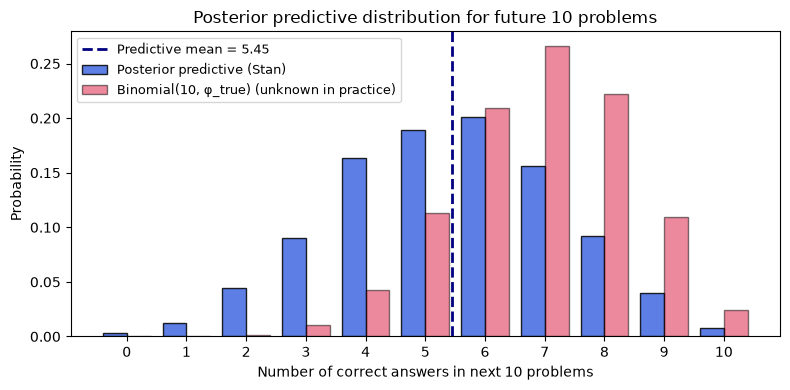

In [9]:
counts = np.bincount(k_new_samples, minlength=N_NEW + 1)
pred_prob = counts / counts.sum()
pred_mean = k_new_samples.mean()
pred_low, pred_high = np.quantile(k_new_samples, [0.025, 0.975])

# 참값 phi를 알고 있을 때의 분포 (비교용)
from scipy.stats import binom
true_prob = binom.pmf(np.arange(N_NEW + 1), N_NEW, PHI_TRUE)

print(f"Predictive mean correct (next {N_NEW}): {pred_mean:.3f}")
print(f"Predictive 95% interval: [{pred_low:.0f}, {pred_high:.0f}]")

xs = np.arange(N_NEW + 1)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(xs - 0.2, pred_prob, width=0.4, color="royalblue", edgecolor="black", alpha=0.85,
       label="Posterior predictive (Stan)")
ax.bar(xs + 0.2, true_prob, width=0.4, color="crimson", edgecolor="black", alpha=0.5,
       label=f"Binomial({N_NEW}, φ_true) (unknown in practice)")
ax.axvline(pred_mean, color="navy", linestyle="--", linewidth=2, label=f"Predictive mean = {pred_mean:.2f}")
ax.set_xticks(xs)
ax.set_xlabel(f"Number of correct answers in next {N_NEW} problems")
ax.set_ylabel("Probability")
ax.set_title(f"Posterior predictive distribution for future {N_NEW} problems")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

사후예측분포는 참값 $\phi_{\text{true}}$ 를 알 때의 이항분포보다 넓다. $\phi$ 에 대한 불확실성이 예측에 함께 반영되기 때문이다.

## 5. 결론

- 관측 데이터(성공 수 $k$)가 prior $\theta \sim \text{Normal}(\mu_0, \sigma_0)$ 를 업데이트해 잠재능력 $\theta$ 의 posterior를 만든다.
- logistic 변환 덕분에 $\theta$ 는 제약 없는 실수 파라메터가 되고, Normal prior와 MCMC를 그대로 사용할 수 있다.
- conjugacy가 없어도 Stan 샘플과 grid 근사가 일치함을 확인했다.
- $\phi$ 의 posterior는 $\theta$ 샘플에 logistic 변환을 적용해 바로 얻는다. 단, $\text{logistic}(E[\theta]) \neq E[\phi]$ 이다 (비선형 변환).
- 시뮬레이션 참값 $\theta_{\text{true}}$ 가 95% credible interval 안에 들어오는지 확인함으로써 추정 절차를 점검할 수 있다. N=20은 작은 표본이므로 구간이 넓다.

## 6. Prior sensitivity: Normal(μ, σ) prior 비교

같은 관측 데이터에 대해 $\theta$ 의 prior를 바꿨을 때 posterior가 어떻게 달라지는지 Stan으로 비교한다.
prior 파라메터를 `data` 로 받도록 모델을 작성했으므로 재컴파일 없이 다시 샘플링할 수 있다.

- 실험 A: Normal(0, 1.5)  (기준 실험, φ 공간에서 거의 균등)
- 실험 B: Normal(0, 0.5)  (θ가 0 근처, 즉 φ≈0.5 라는 강한 믿음)
- 실험 C: Normal(-2, 0.5) (능력이 낮다는 강한 믿음, φ≈0.12)
- 실험 D: Normal(0, 10)   (θ 공간에서 매우 넓은 "모호한" prior)

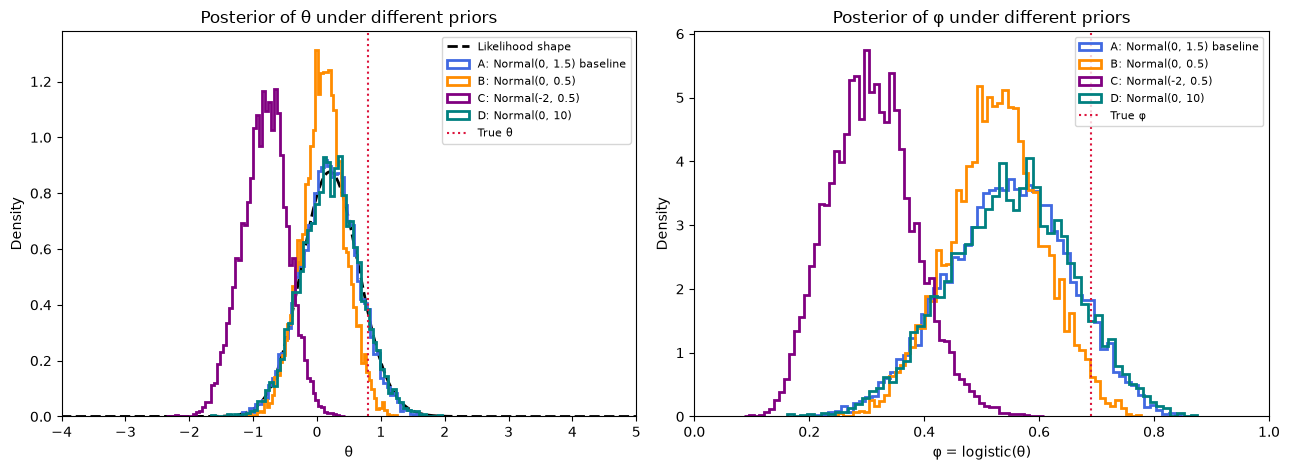

Observed data: k=11 successes out of N=20   (true θ=0.8, true φ=0.690)
----------------------------------------------------------------------
Prior: A: Normal(0, 1.5) baseline
Posterior mean(theta): 0.1896, 95% CrI: (-0.6810, 1.0618)
Posterior mean(phi) : 0.5452, 95% CrI: (0.3360, 0.7430)
Predictive mean correct (next 10): 5.447, 95% interval: [2, 9]
----------------------------------------------------------------------
Prior: B: Normal(0, 0.5)
Posterior mean(theta): 0.0994, 95% CrI: (-0.5800, 0.7687)
Posterior mean(phi) : 0.5242, 95% CrI: (0.3589, 0.6832)
Predictive mean correct (next 10): 5.253, 95% interval: [2, 9]
----------------------------------------------------------------------
Prior: C: Normal(-2, 0.5)
Posterior mean(theta): -0.8314, 95% CrI: (-1.5434, -0.1622)
Posterior mean(phi) : 0.3084, 95% CrI: (0.1760, 0.4595)
Predictive mean correct (next 10): 3.067, 95% interval: [0, 7]
----------------------------------------------------------------------
Prior: D: Normal(0, 10)
Pos

In [10]:
prior_settings = [
    (0.0, 1.5, "A: Normal(0, 1.5) baseline"),
    (0.0, 0.5, "B: Normal(0, 0.5)"),
    (-2.0, 0.5, "C: Normal(-2, 0.5)"),
    (0.0, 10.0, "D: Normal(0, 10)"),
]
colors = ["royalblue", "darkorange", "purple", "teal"]

results = []
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# Likelihood shape on theta (up to proportionality)
theta_plot = np.linspace(-5, 6, 1200)
phi_plot = logistic(theta_plot)
like_shape = np.exp(k * np.log(phi_plot) + (N - k) * np.log1p(-phi_plot))
like_shape /= np.trapezoid(like_shape, theta_plot)
axes[0].plot(theta_plot, like_shape, color="black", linewidth=2, linestyle="--", label="Likelihood shape")

for (m0, s0, name), col in zip(prior_settings, colors):
    fit_i = model.sample(
        data={"N": int(N), "y": y.tolist(), "mu0": m0, "sigma0": s0, "N_new": N_NEW},
        chains=4, parallel_chains=4, iter_warmup=1000, iter_sampling=2000,
        seed=SEED, show_progress=False,
    )
    d = fit_i.draws_pd(vars=["theta", "phi", "k_new"])
    theta_i, phi_i, kn_i = d["theta"].to_numpy(), d["phi"].to_numpy(), d["k_new"].to_numpy()

    results.append({
        "prior": name,
        "theta_mean": theta_i.mean(),
        "theta_ci": np.quantile(theta_i, [0.025, 0.975]),
        "phi_mean": phi_i.mean(),
        "phi_ci": np.quantile(phi_i, [0.025, 0.975]),
        "pred_mean": kn_i.mean(),
        "pred_pi": np.quantile(kn_i, [0.025, 0.975]),
    })

    axes[0].hist(theta_i, bins=60, density=True, histtype="step", linewidth=2, color=col, label=name)
    axes[1].hist(phi_i, bins=60, density=True, histtype="step", linewidth=2, color=col, label=name)

for ax in axes:
    ax.set_ylabel("Density")
axes[0].axvline(THETA_TRUE, color="crimson", linestyle=":", linewidth=1.5, label="True θ")
axes[1].axvline(PHI_TRUE, color="crimson", linestyle=":", linewidth=1.5, label="True φ")
axes[0].set_xlim(-4, 5)
axes[1].set_xlim(0, 1)
axes[0].set_xlabel("θ")
axes[1].set_xlabel("φ = logistic(θ)")
axes[0].set_title("Posterior of θ under different priors")
axes[1].set_title("Posterior of φ under different priors")
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"Observed data: k={k} successes out of N={N}   (true θ={THETA_TRUE}, true φ={PHI_TRUE:.3f})")
for r in results:
    print("-" * 70)
    print(f"Prior: {r['prior']}")
    print(f"Posterior mean(theta): {r['theta_mean']:.4f}, 95% CrI: ({r['theta_ci'][0]:.4f}, {r['theta_ci'][1]:.4f})")
    print(f"Posterior mean(phi) : {r['phi_mean']:.4f}, 95% CrI: ({r['phi_ci'][0]:.4f}, {r['phi_ci'][1]:.4f})")
    print(f"Predictive mean correct (next {N_NEW}): {r['pred_mean']:.3f}, "
          f"95% interval: [{r['pred_pi'][0]:.0f}, {r['pred_pi'][1]:.0f}]")

### 해석

1. **Normal(0, 0.5)의 의미**
- $\theta$ 가 0 근처(φ≈0.5)에 있다는 비교적 강한 사전 믿음이다.
- 데이터가 같아도 posterior가 0 방향으로 수축(shrinkage)하고, 구간 폭도 좁아진다.

2. **Normal(-2, 0.5)의 의미**
- 학생의 능력이 낮다(φ≈logistic(-2)≈0.12)는 강한 사전 믿음이다.
- N=20의 데이터만으로는 이 prior를 충분히 이기지 못해 posterior가 참값보다 뚜렷하게 낮은 쪽으로 당겨진다. 사후예측 정답 수도 낮아진다.

3. **Normal(0, 10)의 의미**
- $\theta$ 공간에서는 "정보가 거의 없는" prior처럼 보이지만, φ 공간으로 옮기면 0과 1 근처에 질량이 몰린 U자형 prior가 된다(7절).
- 데이터가 극단적이지 않으면 posterior는 likelihood와 거의 같아지지만, 만약 20문제를 모두 맞추거나(k=N) 모두 틀리면 posterior가 매우 길게 퍼진다.
- 즉, "넓은 prior = 무정보 prior"는 아니다. 어떤 파라메터 공간에서 보는가에 따라 의미가 달라진다.

4. **종합**
- 표본 수가 작거나 prior가 강할수록 posterior와 예측 결과의 차이가 커진다.
- posterior는 `likelihood(데이터)` 와 `prior(사전 믿음)` 의 절충 결과다.

## 7. Normal prior on θ → φ 공간에서의 prior 모양

$\theta \sim \text{Normal}(\mu, \sigma)$ 일 때 $\phi = \text{logistic}(\theta)$ 의 밀도는 변수변환으로

$$
p(\phi) = \text{Normal}(\text{logit}(\phi) \mid \mu, \sigma) \cdot \frac{1}{\phi(1-\phi)}
$$

이다 (logit-normal 분포). 아래 격자는 $\mu$ 와 $\sigma$ 가 바뀔 때 φ 공간의 prior 모양이 어떻게 달라지는지 보여준다.

- $\sigma$ 가 작으면: $\text{logistic}(\mu)$ 근처에 봉우리
- $\sigma \approx 1.5$ ~ $1.8$: φ 공간에서 거의 균등 (μ=0일 때)
- $\sigma$ 가 크면: 0과 1 근처에 질량이 몰리는 U자형
- $\mu > 0$: 1 쪽으로 치우침, $\mu < 0$: 0 쪽으로 치우침

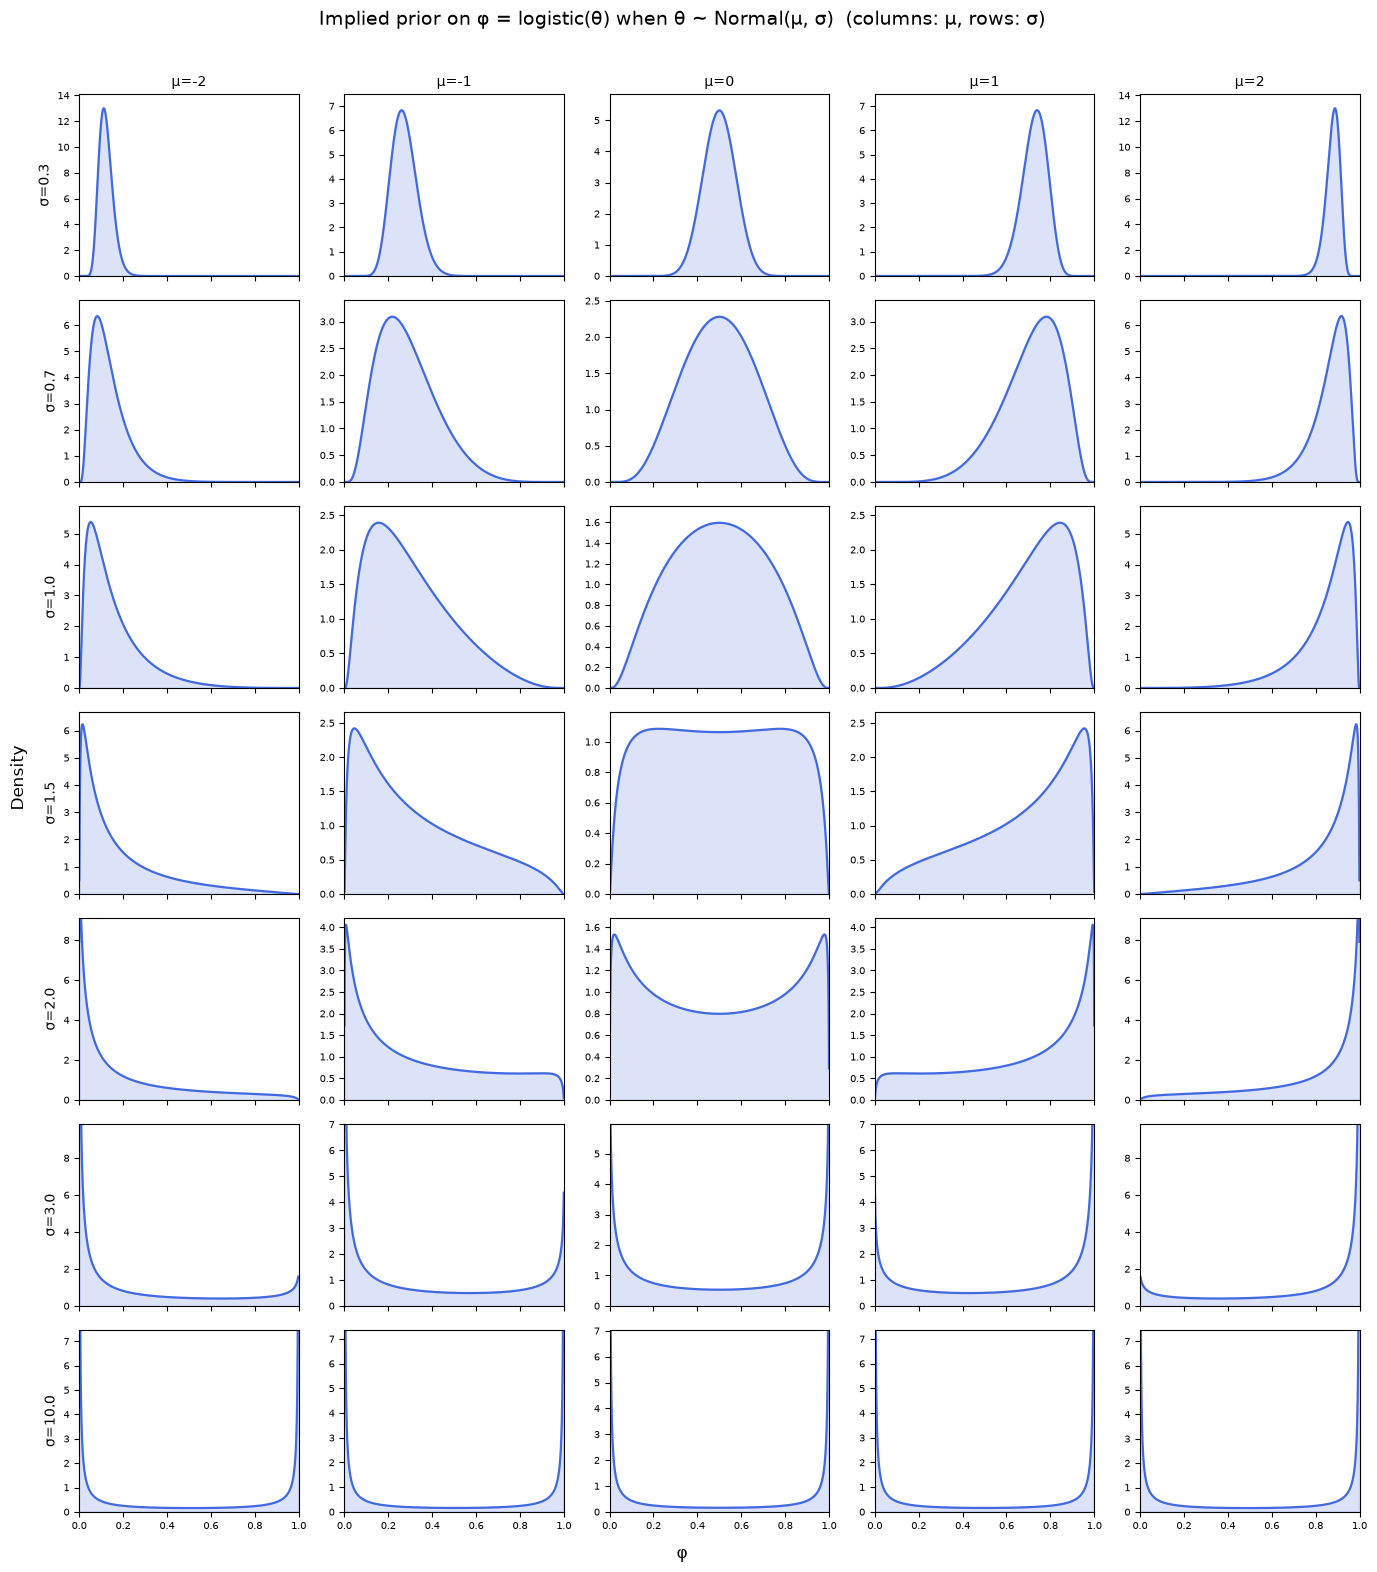

In [11]:
mu_values = [-2, -1, 0, 1, 2]
sigma_values = [0.3, 0.7, 1.0, 1.5, 2.0, 3.0, 10.0]

phi_x = np.linspace(0.0005, 0.9995, 1000)
fig, axes = plt.subplots(len(sigma_values), len(mu_values), figsize=(14, 16), sharex=True)

for row, s in enumerate(sigma_values):
    for col, m in enumerate(mu_values):
        ax = axes[row, col]
        pdf = norm.pdf(logit(phi_x), m, s) / (phi_x * (1 - phi_x))
        ax.plot(phi_x, pdf, color="royalblue", linewidth=1.6)
        ax.fill_between(phi_x, pdf, color="royalblue", alpha=0.18)
        ax.set_xlim(0, 1)

        # Each panel uses its own y-scale; clip extreme spikes near the boundary for readability
        ymax = float(np.quantile(pdf, 0.99))
        ax.set_ylim(0, ymax * 1.1)

        if row == 0:
            ax.set_title(f"μ={m}", fontsize=10)
        if col == 0:
            ax.set_ylabel(f"σ={s}", fontsize=10)
        ax.tick_params(labelsize=7)

fig.suptitle("Implied prior on φ = logistic(θ) when θ ~ Normal(μ, σ)  (columns: μ, rows: σ)", fontsize=14)
fig.supxlabel("φ", fontsize=12)
fig.supylabel("Density", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

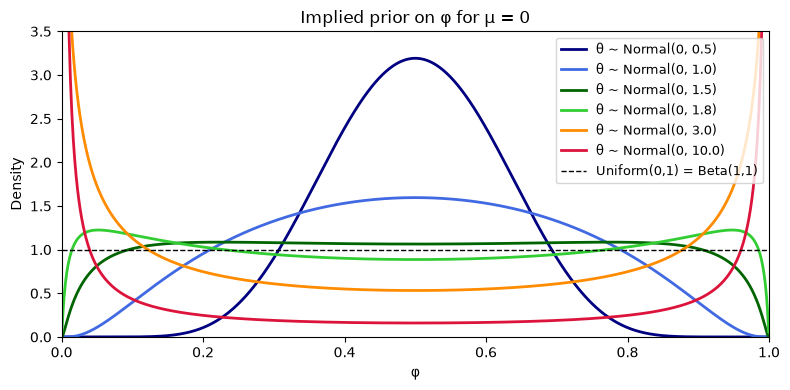

In [12]:
# μ=0 에서 σ에 따른 φ-prior 모양을 한 그림에 겹쳐 보기
fig, ax = plt.subplots(figsize=(8, 4))
for s, col in zip([0.5, 1.0, 1.5, 1.8, 3.0, 10.0],
                  ["navy", "royalblue", "darkgreen", "limegreen", "darkorange", "crimson"]):
    pdf = norm.pdf(logit(phi_x), 0, s) / (phi_x * (1 - phi_x))
    ax.plot(phi_x, pdf, linewidth=2, color=col, label=f"θ ~ Normal(0, {s})")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="Uniform(0,1) = Beta(1,1)")
ax.set_ylim(0, 3.5)
ax.set_xlim(0, 1)
ax.set_xlabel("φ")
ax.set_ylabel("Density")
ax.set_title("Implied prior on φ for μ = 0")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Logistic 변환에 따른 밀도의 변화: θ ~ Normal(0, 1) → φ = logistic(θ)

- 가운데 그림: logistic 곡선 $\phi = \text{logistic}(\theta)$
- 아래 그림 (θ 축): $\theta \sim \text{Normal}(\mu=0, \sigma=1)$ 의 pdf
- 왼쪽 그림 (φ 축, 세로 방향): 변환된 $\phi$ 의 pdf $\;p(\phi) = \text{Normal}(\text{logit}(\phi)\mid\mu,\sigma)\,/\,\{\phi(1-\phi)\}$

점선은 $\theta = \mu \pm \sigma,\ \mu \pm 2\sigma$ 가 곡선을 거쳐 φ 축의 어느 값으로 옮겨지는지 보여준다.
색칠한 구간 $\mu-\sigma \le \theta \le \mu+\sigma$ 과 그 상 $[\text{logistic}(\mu-\sigma), \text{logistic}(\mu+\sigma)]$ 은 같은 확률(≈68.3%)을 가진다.

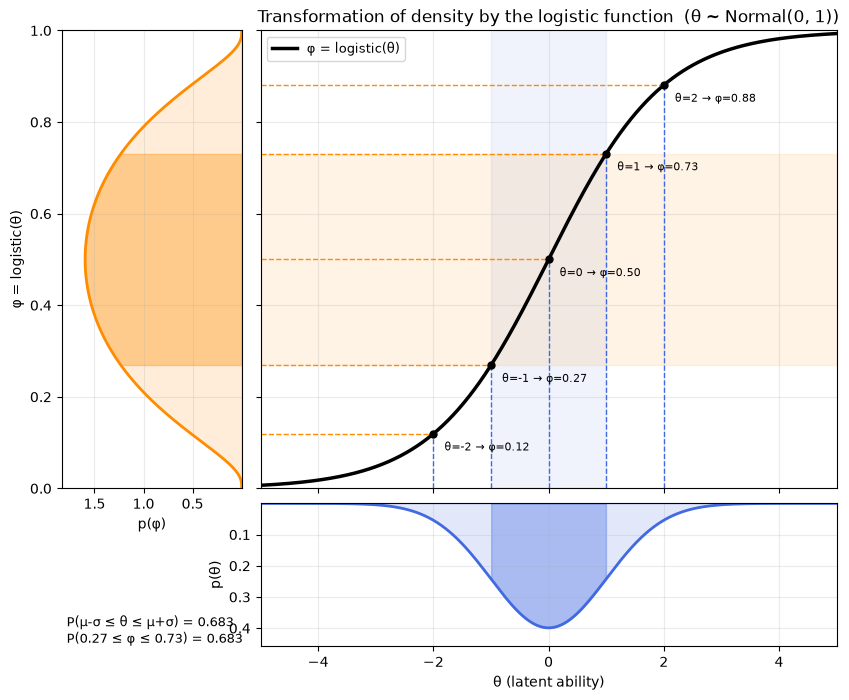

In [13]:
from scipy.stats import norm

mu, sigma = 0.0, 1.0

theta = np.linspace(-5, 5, 1000)
phi = np.linspace(0.0005, 0.9995, 1000)
pdf_theta = norm.pdf(theta, mu, sigma)
pdf_phi = norm.pdf(logit(phi), mu, sigma) / (phi * (1 - phi))   # change of variables

fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[1, 3.2], height_ratios=[3.2, 1],
                      wspace=0.05, hspace=0.05)
ax_main = fig.add_subplot(gs[0, 1])
ax_phi = fig.add_subplot(gs[0, 0], sharey=ax_main)   # phi pdf, drawn vertically
ax_theta = fig.add_subplot(gs[1, 1], sharex=ax_main)  # theta pdf, along the theta axis

# ---- main: logistic curve ----
ax_main.plot(theta, logistic(theta), color="black", linewidth=2.5, label="φ = logistic(θ)")

# band mu ± sigma and its image
th1, th2 = mu - sigma, mu + sigma
ph1, ph2 = logistic(th1), logistic(th2)
ax_main.axvspan(th1, th2, color="royalblue", alpha=0.08)
ax_main.axhspan(ph1, ph2, color="darkorange", alpha=0.10)

# guide lines: theta -> curve -> phi
for thv in [mu - 2 * sigma, mu - sigma, mu, mu + sigma, mu + 2 * sigma]:
    phv = logistic(thv)
    ax_main.plot([thv, thv], [0, phv], color="royalblue", linestyle="--", linewidth=1)
    ax_main.plot([theta[0], thv], [phv, phv], color="darkorange", linestyle="--", linewidth=1)
    ax_main.plot(thv, phv, "o", color="black", markersize=5)
    ax_main.annotate(f"θ={thv:g} → φ={phv:.2f}", (thv, phv), textcoords="offset points",
                     xytext=(8, -12), fontsize=8)

ax_main.set_xlim(theta[0], theta[-1])
ax_main.set_ylim(0, 1)
ax_main.set_title(f"Transformation of density by the logistic function  (θ ~ Normal({mu:g}, {sigma:g}))")
ax_main.legend(loc="upper left", fontsize=9)
ax_main.tick_params(labelbottom=False, labelleft=False)
ax_main.grid(alpha=0.25)

# ---- bottom: pdf of theta along the x-axis ----
ax_theta.plot(theta, pdf_theta, color="royalblue", linewidth=2)
ax_theta.fill_between(theta, pdf_theta, color="royalblue", alpha=0.15)
m = (theta >= th1) & (theta <= th2)
ax_theta.fill_between(theta[m], pdf_theta[m], color="royalblue", alpha=0.35)
ax_theta.set_ylim(pdf_theta.max() * 1.15, 0)   # hang downward from the theta axis
ax_theta.set_xlabel("θ (latent ability)")
ax_theta.set_ylabel("p(θ)")
ax_theta.set_yticks([0.1, 0.2, 0.3, 0.4])
ax_theta.grid(alpha=0.25)

# ---- left: pdf of phi drawn vertically along the y-axis ----
ax_phi.plot(pdf_phi, phi, color="darkorange", linewidth=2)
ax_phi.fill_betweenx(phi, pdf_phi, color="darkorange", alpha=0.15)
m = (phi >= ph1) & (phi <= ph2)
ax_phi.fill_betweenx(phi[m], pdf_phi[m], color="darkorange", alpha=0.35)
ax_phi.set_xlim(pdf_phi.max() * 1.15, 0)     # grow leftward from the phi axis
ax_phi.set_ylabel("φ = logistic(θ)")
ax_phi.set_xlabel("p(φ)")
ax_phi.set_xticks([0.5, 1.0, 1.5])
ax_phi.grid(alpha=0.25)

# probability of the band is the same in both spaces
p_theta = norm.cdf(th2, mu, sigma) - norm.cdf(th1, mu, sigma)
from scipy.integrate import quad
p_phi, _ = quad(lambda t: norm.pdf(logit(t), mu, sigma) / (t * (1 - t)), ph1, ph2)
fig.text(0.13, 0.13, f"P(μ-σ ≤ θ ≤ μ+σ) = {p_theta:.3f}\nP({ph1:.2f} ≤ φ ≤ {ph2:.2f}) = {p_phi:.3f}",
         fontsize=9, va="center")

plt.show()